# Feature-Enhanced NCF (Staged Ablations)

**Model:** Neural Collaborative Filtering with side features  
**Purpose:** Test whether adding content and contextual signals improves over the ID-only NCF baseline.

**Staged ablations:**
- Stage 1: ID embeddings + `item_semantic_embedding_static` (SBERT 384-dim)
- Stage 2: Stage 1 + structured item metadata + item temporal popularity features
- Stage 3: Stage 2 + user-item matching signals + user history features

**Input files:** `App1_train.pkl`, `App1_val.pkl`, `App1_test.pkl`  
**Evaluation:** Same 5k sampled users as ID-only NCF (`eval_sample_users.csv`)

| Stage              | Features Added |
|-------------------|----------------|
| Baseline (ID-only)| user_id, book_id embeddings only |
| Stage 1           | + item_semantic_embedding_static (SBERT, 384-dim, projected to 32-dim) |
| Stage 2           | + static item metadata and item temporal popularity features |
| Stage 3           | + user history and user-item matching features |

## 0. Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/My Drive/BT4222Project/"
K = 10
SEED = 4222

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Mounted at /content/drive
Device : cuda


## 1. Load Splits

All feature columns are available in the App1 pkl files.  
We load the full dataframes here — each stage selects its own feature subset.

In [2]:
train_df= pd.read_pickle(DATA_DIR + "App1_train.pkl")
val_df= pd.read_pickle(DATA_DIR + "App1_val.pkl")
test_df= pd.read_pickle(DATA_DIR + "App1_test.pkl")

for df in [train_df, val_df, test_df]:
    df["user_id"]    = df["user_id"].astype(str)
    df["book_id"]    = df["book_id"].astype(str)
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df.sort_values(["user_id", "event_time"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users")
print(f"\nColumns: {train_df.columns.tolist()}")

Train : 6,017,121 rows  |  454,189 users
Val   : 1,317,799 rows  |  315,520 users
Test  : 1,435,444 rows  |  315,520 users

Columns: ['user_id', 'book_id', 'review_id', 'event_time', 'title', 'description', 'description_truncated', 'has_meaningful_description', 'publication_year', 'num_pages', 'language_code_collapsed', 'format_collapsed', 'is_ebook', 'authors_standardized', 'main_author_id', 'author_interactions_count_before_t', 'top_shelf_tags', 'item_text_for_embedding', 'item_semantic_embedding_static', 'item_num_pages', 'user_page_preference_before_t', 'num_pages_preference_gap', 'user_hist_interaction_count_before_t', 'days_since_user_last_interaction', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'user_author_interaction_share_before_t', 'user_hist_author_diversity_before_t', 'user_profile_embedding_similarity']


## 2. Label Encoding

In [3]:
user_enc = LabelEncoder()
item_enc = LabelEncoder()

all_users = pd.concat([train_df, val_df, test_df])["user_id"].unique()
all_items = pd.concat([train_df, val_df, test_df])["book_id"].unique()
user_enc.fit(all_users)
item_enc.fit(all_items)

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

N        = len(pd.concat([train_df, val_df, test_df]))
sparsity = N / (num_users * num_items)
print(f"Users (U)        : {num_users:,}")
print(f"Items (I)        : {num_items:,}")
print(f"Interactions (N) : {N:,}")
print(f"Density          : {sparsity * 100:.4f}%")

def encode_df(df):
    d = df[
        df["user_id"].isin(user_enc.classes_) &
        df["book_id"].isin(item_enc.classes_)
    ].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df)
val_enc   = encode_df(val_df)
test_enc  = encode_df(test_df)

# Lookup dicts for fast evaluation
item_to_idx = {item: idx for idx, item in enumerate(item_enc.classes_)}
user_to_idx = {u: idx   for idx, u   in enumerate(user_enc.classes_)}

Users (U)        : 454,189
Items (I)        : 123,087
Interactions (N) : 8,770,364
Density          : 0.0157%


## 3. Categorical Encoders for Side Features

Encode `format_collapsed`, `language_code_collapsed`, and `main_author_id`  
as integer indices for use in the side-feature embeddings.

In [4]:
format_enc = LabelEncoder()
lang_enc   = LabelEncoder()
author_enc = LabelEncoder()

all_formats = pd.concat([train_df, val_df, test_df])["format_collapsed"].fillna("unknown").unique()
all_langs   = pd.concat([train_df, val_df, test_df])["language_code_collapsed"].fillna("unknown").unique()
all_authors = pd.concat([train_df, val_df, test_df])["main_author_id"].fillna("unknown").astype(str).unique()

format_enc.fit(all_formats)
lang_enc.fit(all_langs)
author_enc.fit(all_authors)

num_formats = len(format_enc.classes_)
num_langs = len(lang_enc.classes_)
num_authors = len(author_enc.classes_)

print(f"Formats  : {num_formats}")
print(f"Languages: {num_langs}")
print(f"Authors  : {num_authors}")

def encode_categoricals(df):
    d = df.copy()
    d["format_idx"] = format_enc.transform(
        d["format_collapsed"].fillna("unknown"))
    d["lang_idx"] = lang_enc.transform(
        d["language_code_collapsed"].fillna("unknown"))
    d["author_idx"] = author_enc.transform(
        d["main_author_id"].fillna("unknown").astype(str))
    return d

train_enc = encode_categoricals(train_enc)
val_enc = encode_categoricals(val_enc)
test_enc = encode_categoricals(test_enc)
print("Categorical encoding done.")

Formats  : 11
Languages: 79
Authors  : 24992
Categorical encoding done.


## 4. Numerical Feature Scaling

Scale all numerical side features using `StandardScaler`.  
Fit on training set only — transform val and test using the same scaler.  
Missing values are filled with 0 (mean after scaling).

In [5]:
## 4. Numerical Feature Scaling

# Only scale columns that are NOT re-scaled later in Stage 2
NUMERICAL_COLS = [
    # Stage 3 — user-item matching
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    # Stage 3 — user history
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    "days_since_user_last_interaction",
    "user_author_interaction_share_before_t",
]

NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in train_enc.columns]
print(f"Scaling {len(NUMERICAL_COLS)} numerical columns")

for df in [train_enc, val_enc, test_enc]:
    for col in NUMERICAL_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

base_scaler = StandardScaler()
train_enc[NUMERICAL_COLS] = base_scaler.fit_transform(train_enc[NUMERICAL_COLS].fillna(0))
val_enc[NUMERICAL_COLS]   = base_scaler.transform(val_enc[NUMERICAL_COLS].fillna(0))
test_enc[NUMERICAL_COLS]  = base_scaler.transform(test_enc[NUMERICAL_COLS].fillna(0))

print("Base scaling done.")

Scaling 6 numerical columns
Base scaling done.


## 5. Negative Sampling (Top-1000 Popular Books)

Same strategy as ID-only NCF — 1:1 ratio from top-1000 popular books  
the user has not seen across any split.

In [6]:
## 5. Negative Sampling (Top-1000 Popular Books, timestamp-anchored)

top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)

# Train-only history for training negatives
user_train_history = (
    train_df.groupby("user_id")["book_id"]
    .apply(set)
    .to_dict()
)

# Keep positive rows WITH event_time
pos = train_enc[["user_id", "book_id", "user_idx", "item_idx", "event_time"]].copy()
pos["label"] = 1

neg_rows = []

for row in tqdm(pos.itertuples(index=False), total=len(pos), desc="Sampling negatives"):
    user_id = row.user_id
    uidx = row.user_idx
    ref_time = row.event_time

    seen = user_train_history.get(user_id, set())
    pool = [b for b in top_1000_books if b not in seen and b in item_to_idx]

    if not pool:
        continue

    sampled_neg = random.choice(pool)

    neg_rows.append({
        "user_id": user_id,
        "book_id": sampled_neg,
        "user_idx": uidx,
        "item_idx": item_to_idx[sampled_neg],
        "event_time": ref_time,   # inherit positive timestamp
        "label": 0,
    })

neg = pd.DataFrame(neg_rows)

train_with_neg = (
    pd.concat([pos, neg], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Train rows (with negatives): {len(train_with_neg):,}")
print(train_with_neg["label"].value_counts())

Sampling negatives: 100%|██████████| 6017121/6017121 [04:22<00:00, 22897.68it/s]


Train rows (with negatives): 12,034,242
label
1    6017121
0    6017121
Name: count, dtype: int64


In [7]:
## 5A. Stage 2 temporal lookup helpers

import bisect

# Build temporal history from TRAIN only
train_hist_temporal = train_df[["book_id", "main_author_id", "event_time"]].copy()
train_hist_temporal["main_author_id"] = (
    train_hist_temporal["main_author_id"]
    .fillna("unknown")
    .astype(str)
)
train_hist_temporal = (
    train_hist_temporal.sort_values("event_time")
    .reset_index(drop=True)
)

book_time_lists = (
    train_hist_temporal.groupby("book_id")["event_time"]
    .apply(list)
    .to_dict()
)

author_time_lists = (
    train_hist_temporal.groupby("main_author_id")["event_time"]
    .apply(list)
    .to_dict()
)

item_to_author = (
    pd.concat([train_df, val_df, test_df], ignore_index=True)[["book_id", "main_author_id"]]
    .copy()
)
item_to_author["main_author_id"] = item_to_author["main_author_id"].fillna("unknown").astype(str)
item_to_author = (
    item_to_author.drop_duplicates("book_id")
    .set_index("book_id")["main_author_id"]
    .to_dict()
)

def compute_item_temporal_features(book_id, ref_time):
    """
    Compute dynamic Stage 2 temporal item features using TRAIN history only.
    The reference time ref_time is inherited from the positive interaction row.
    """
    ref_time = pd.Timestamp(ref_time)

    # Book-level history
    btimes = book_time_lists.get(book_id, [])
    n_before = bisect.bisect_left(btimes, ref_time)

    if n_before == 0:
        book_interactions_count_before_t = 0.0
        days_since_book_last_interaction = 0.0
    else:
        book_interactions_count_before_t = float(n_before)
        last_time = btimes[n_before - 1]
        days_since_book_last_interaction = float(
            (ref_time - last_time).total_seconds() / 86400.0
        )

    # Author-level history
    author_id = item_to_author.get(book_id, "unknown")
    atimes = author_time_lists.get(author_id, [])
    author_n_before = bisect.bisect_left(atimes, ref_time)
    author_interactions_count_before_t = float(author_n_before)

    return {
        "book_interactions_count_before_t": book_interactions_count_before_t,
        "days_since_book_last_interaction": days_since_book_last_interaction,
        "author_interactions_count_before_t": author_interactions_count_before_t,
    }

## 6. Dataset

`FeatureNCFDataset` supports all stages via a `feature_cols` parameter.  
For training it uses the negatively-sampled set.  
For val/test it uses all interactions (all treated as positives).

In [8]:
class FeatureNCFDataset(Dataset):
    """
    Supports ID-only and all feature-enhanced stages.
    feature_cols: list of numerical feature column names to include.
    cat_cols    : list of categorical index column names to include.
    emb_col     : name of the static embedding column (or None).
    """
    def __init__(self, df, feature_cols=None, cat_cols=None, emb_col=None,
                 label_col="label"):
        self.users   = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items   = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels  = torch.tensor(df[label_col].values,  dtype=torch.float32)

        self.feature_cols = feature_cols or []
        self.cat_cols     = cat_cols     or []
        self.emb_col      = emb_col

        if self.feature_cols:
            self.num_feats = torch.tensor(
                df[self.feature_cols].values, dtype=torch.float32)
        if self.cat_cols:
            self.cat_feats = torch.tensor(
                df[self.cat_cols].values, dtype=torch.long)
        if self.emb_col:
            self.emb_feats = torch.tensor(
                np.vstack(df[self.emb_col].values), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        batch = {
            "user": self.users[idx],
            "item": self.items[idx],
            "label": self.labels[idx],
        }
        if self.feature_cols:
            batch["num_feats"] = self.num_feats[idx]
        if self.cat_cols:
            batch["cat_feats"] = self.cat_feats[idx]
        if self.emb_col:
            batch["emb_feats"] = self.emb_feats[idx]
        return batch

print("FeatureNCFDataset defined.")

FeatureNCFDataset defined.


## 7. Feature-Enhanced NCF Model

Two-branch architecture:
- **Collaborative branch:** user_id + book_id embeddings (same as ID-only NCF)
- **Side-feature branch:** processes item/user features separately

Both branches are concatenated and passed through a shared MLP for prediction.

The model is configurable — pass only the features relevant to each stage.

In [9]:
class FeatureEnhancedNCF(nn.Module):
    def __init__(self,
                 num_users, num_items,
                 embedding_dim=32,
                 # Categorical side feature sizes (Stage 2+)
                 num_formats=0, num_langs=0, num_authors=0,
                 cat_emb_dim=8,
                 # Numerical feature count (Stage 2+)
                 num_numerical=0,
                 # Static embedding dim (Stage 1+)
                 static_emb_dim=0,
                 dropout=0.5):
        super().__init__()

        # Collaborative branch
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Side-feature branch
        self.use_static_emb = static_emb_dim > 0
        self.use_cats       = num_formats > 0
        self.use_numerical  = num_numerical > 0

        if self.use_static_emb:
            # Project 384-dim SBERT down to embedding_dim
            self.static_proj = nn.Sequential(
                nn.Linear(static_emb_dim, embedding_dim),
                nn.ReLU()
            )

        if self.use_cats:
            self.format_emb = nn.Embedding(num_formats + 1, cat_emb_dim, padding_idx=0)
            self.lang_emb   = nn.Embedding(num_langs   + 1, cat_emb_dim, padding_idx=0)
            self.author_emb = nn.Embedding(num_authors + 1, cat_emb_dim, padding_idx=0)

        # MLP input size
        cf_dim      = 2 * embedding_dim
        side_dim    = 0
        if self.use_static_emb: side_dim += embedding_dim
        if self.use_cats:       side_dim += 3 * cat_emb_dim
        if self.use_numerical:  side_dim += num_numerical

        mlp_input_dim = cf_dim + side_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, user, item, emb_feats=None, cat_feats=None, num_feats=None):
        # Collaborative branch
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)

        # Side-feature branch
        side_parts = []
        if self.use_static_emb and emb_feats is not None:
            side_parts.append(self.static_proj(emb_feats))
        if self.use_cats and cat_feats is not None:
            fmt_e    = self.format_emb(cat_feats[:, 0])
            lang_e   = self.lang_emb(cat_feats[:, 1])
            author_e = self.author_emb(cat_feats[:, 2])
            side_parts.extend([fmt_e, lang_e, author_e])
        if self.use_numerical and num_feats is not None:
            side_parts.append(num_feats)

        if side_parts:
            x = torch.cat([x] + side_parts, dim=1)

        return self.mlp(x).squeeze(1)

print("FeatureEnhancedNCF defined.")

FeatureEnhancedNCF defined.


## 8. Training Function

In [10]:
def train_stage(model, train_loader, val_loader, stage_name,
                num_epochs=10, patience=5, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss, pc = float("inf"), 0
    train_losses, val_losses = [], []
    save_path = f"best_ncf_{stage_name}.pt"

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_loss = 0
        for batch in tqdm(train_loader,
                          desc=f"[{stage_name}] Epoch {epoch+1:02d}",
                          leave=False):
            user  = batch["user"].to(DEVICE)
            item  = batch["item"].to(DEVICE)
            label = batch["label"].to(DEVICE)
            emb   = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
            cat   = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
            num   = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None

            optimizer.zero_grad()
            out  = torch.sigmoid(model(user, item, emb, cat, num))
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)
        train_losses.append(avg_train)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                user  = batch["user"].to(DEVICE)
                item  = batch["item"].to(DEVICE)
                label = batch["label"].to(DEVICE)
                emb   = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
                cat   = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
                num   = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None
                out   = torch.sigmoid(model(user, item, emb, cat, num))
                val_loss += criterion(out, label).item()

        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)
        print(f"  [{stage_name}] Epoch {epoch+1:02d}  "
              f"Train: {avg_train:.4f}  Val: {avg_val:.4f}")

        if avg_val < best_loss:
            best_loss = avg_val; pc = 0
            torch.save(model.state_dict(), save_path)
            print(f"    ✓ Saved (val: {best_loss:.4f})")
        else:
            pc += 1
            if pc >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    # Loss curve
    plt.figure(figsize=(7, 3))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses,   label="Val")
    plt.title(f"{stage_name} — Loss Curves")
    plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
    plt.legend(); plt.tight_layout(); plt.show()

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"  Loaded best weights from {save_path}")
    return model

print("train_stage defined.")

train_stage defined.


## 9. Evaluation Function

In [11]:
def evaluate_stage(model, eval_rows, user_train_seen,
                   item_to_idx, user_to_idx, stage_name,
                   item_static_df=None, emb_col=None, cat_cols=None,
                   static_num_cols=None, temporal_num_cols=None,
                   stage_num_scaler=None,
                   EVAL_NEG_SAMPLES=999):

    model.eval()

    emb_lookup, cat_lookup, static_num_lookup = {}, {}, {}

    if item_static_df is not None:
        item_rows = item_static_df.drop_duplicates("item_idx").set_index("item_idx")

        if emb_col and emb_col in item_rows.columns:
            emb_lookup = item_rows[emb_col].to_dict()

        if cat_cols and all(c in item_rows.columns for c in cat_cols):
            cat_lookup = {
                idx: row[cat_cols].values.astype(int).tolist()
                for idx, row in item_rows[cat_cols].iterrows()
            }

        if static_num_cols and all(c in item_rows.columns for c in item_rows.columns if c in static_num_cols):
            static_num_lookup = {
                idx: row[static_num_cols].values.astype(float).tolist()
                for idx, row in item_rows[static_num_cols].iterrows()
            }

    idx_to_item = {idx: item for item, idx in item_to_idx.items()}

    EMB_DIM = 384
    n_cats = len(cat_cols) if cat_cols else 0
    n_static = len(static_num_cols) if static_num_cols else 0
    n_temporal = len(temporal_num_cols) if temporal_num_cols else 0
    n_nums = n_static + n_temporal

    all_preds_rank = []
    all_targets_rank = []
    eval_user_ids = []

    temporal_cache = {}

    with torch.no_grad():
        for row in tqdm(eval_rows, desc=f"Evaluating {stage_name}"):
            uid = row["user_id"]
            target_book = row["book_id"]
            ref_time = pd.Timestamp(row["event_time"])

            if uid not in user_to_idx or target_book not in item_to_idx:
                continue

            uidx = user_to_idx[uid]
            target_idx = item_to_idx[target_book]

            seen = user_train_seen.get(uid, set()) | {target_book}
            neg_pool = [b for b in top_1000_books if b not in seen and b in item_to_idx]

            if len(neg_pool) == 0:
                continue

            negs = random.sample(neg_pool, min(EVAL_NEG_SAMPLES, len(neg_pool)))

            candidates = [target_book] + negs
            candidate_idx = [item_to_idx[b] for b in candidates]
            n_cands = len(candidate_idx)

            u_t = torch.tensor([uidx] * n_cands, dtype=torch.long).to(DEVICE)
            i_t = torch.tensor(candidate_idx, dtype=torch.long).to(DEVICE)

            emb_t = None
            if emb_lookup:
                emb_arr = np.array([
                    emb_lookup.get(idx, np.zeros(EMB_DIM, dtype=np.float32))
                    for idx in candidate_idx
                ], dtype=np.float32)
                emb_t = torch.tensor(emb_arr, dtype=torch.float32).to(DEVICE)

            cat_t = None
            if cat_lookup:
                cat_arr = np.array([
                    cat_lookup.get(idx, [0] * n_cats)
                    for idx in candidate_idx
                ], dtype=np.int64)
                cat_t = torch.tensor(cat_arr, dtype=torch.long).to(DEVICE)

            num_t = None
            if n_nums > 0:
                num_rows = []

                for idx in candidate_idx:
                    static_part = static_num_lookup.get(idx, [0.0] * n_static)

                    temporal_part = []
                    if temporal_num_cols:
                        book_id = idx_to_item[idx]
                        cache_key = (book_id, ref_time)

                        if cache_key not in temporal_cache:
                            temporal_cache[cache_key] = compute_item_temporal_features(book_id, ref_time)

                        temp_feats = temporal_cache[cache_key]
                        temporal_part = [temp_feats.get(c, 0.0) for c in temporal_num_cols]

                    num_rows.append(static_part + temporal_part)

                num_arr = np.array(num_rows, dtype=np.float32)

                if stage_num_scaler is not None:
                    num_arr_df = pd.DataFrame(num_arr, columns=(static_num_cols or []) + (temporal_num_cols or []))
                    num_arr = stage_num_scaler.transform(num_arr_df)

                num_t = torch.tensor(num_arr, dtype=torch.float32).to(DEVICE)

            scores = torch.sigmoid(model(u_t, i_t, emb_t, cat_t, num_t)).cpu().numpy()

            score_vec = np.full(len(item_to_idx), -np.inf, dtype=np.float32)
            for idx, score in zip(candidate_idx, scores):
                score_vec[idx] = score

            all_preds_rank.append(score_vec)
            all_targets_rank.append(target_idx)
            eval_user_ids.append(uid)

    all_preds_rank = np.array(all_preds_rank)
    all_targets_rank = np.array(all_targets_rank)

    hr = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
    mapk = map_at_k(all_preds_rank, all_targets_rank, k=K)
    ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)

    print(f"\n  {stage_name} — Results (K={K}, {len(all_targets_rank):,} users)")
    print(f"  HR@{K}  : {hr:.4f}")
    print(f"  MAP@{K} : {mapk:.4f}")
    print(f"  nDCG@{K}: {ndcg:.4f}")

    return {
        f"HR@{K}": hr,
        f"MAP@{K}": mapk,
        f"nDCG@{K}": ndcg,
        "all_preds_rank": all_preds_rank,
        "all_targets_rank": all_targets_rank,
        "eval_user_ids": eval_user_ids
    }

## 10. Evaluation Metrics

HitRate@K, MAP@K, nDCG@K — reused from LSTM notebook.  
Scalar nDCG

In [12]:
def hit_rate_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    return np.mean([int(t in top) for t, top in zip(targets, top_k)])

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k_rank(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

def ndcg_at_k_scalar(relevances, k):
    """ scalar nDCG."""
    relevances = np.asarray(relevances)[:k]
    if relevances.size == 0:
        return 0.0
    dcg  = np.sum((2**relevances - 1) / np.log2(np.arange(2, relevances.size + 2)))
    idcg = np.sum((2**np.sort(relevances)[::-1] - 1) /
                  np.log2(np.arange(2, relevances.size + 2)))
    return dcg / idcg if idcg > 0 else 0.0

print("Evaluation functions ready.")

Evaluation functions ready.


## 11. Load Evaluation Users

Load the same 5k sampled users saved by the ID-only NCF notebook.

In [13]:
## 10. Load Evaluation Users

sampled_user_ids = pd.read_csv(DATA_DIR + "eval_sample_users.csv").iloc[:, 0].astype(str).tolist()
print(f"Loaded {len(sampled_user_ids):,} sampled evaluation users")

user_train_seen = train_df.groupby("user_id")["book_id"].apply(set).to_dict()

# Use one positive test row per sampled user for evaluation
test_eval_base = (
    test_enc.sort_values(["user_id", "event_time"])
    .groupby("user_id")
    .first()
    .reset_index()
)

test_eval_base = test_eval_base[
    test_eval_base["user_id"].isin(sampled_user_ids)
].copy()

eval_rows = test_eval_base[["user_id", "book_id", "event_time"]].to_dict("records")
print(f"Evaluating on {len(eval_rows):,} users")

Loaded 5,000 sampled evaluation users
Evaluating on 5,000 users


Building master feature table

In [14]:
item_static_all = pd.concat([train_enc, val_enc, test_enc], ignore_index=True)
item_static_all = item_static_all.drop_duplicates("item_idx").reset_index(drop=True)

## 12. Stage 1 — ID Embeddings + item_semantic_embedding_static

Adds the 384-dim SBERT embedding to the collaborative signal.  
Tests whether semantic content improves over ID-only embeddings.

Training Stage 1...


  [stage1] Epoch 01  Train: 0.3958  Val: 0.4034
    ✓ Saved (val: 0.4034)


  [stage1] Epoch 02  Train: 0.3688  Val: 0.3803
    ✓ Saved (val: 0.3803)


  [stage1] Epoch 03  Train: 0.3456  Val: 0.3778
    ✓ Saved (val: 0.3778)


  [stage1] Epoch 04  Train: 0.3217  Val: 0.3668
    ✓ Saved (val: 0.3668)


  [stage1] Epoch 05  Train: 0.3029  Val: 0.3671


  [stage1] Epoch 06  Train: 0.2881  Val: 0.3696


  [stage1] Epoch 07  Train: 0.2762  Val: 0.3893


  [stage1] Epoch 08  Train: 0.2661  Val: 0.3892


  [stage1] Epoch 09  Train: 0.2575  Val: 0.3949
  Early stopping at epoch 9.


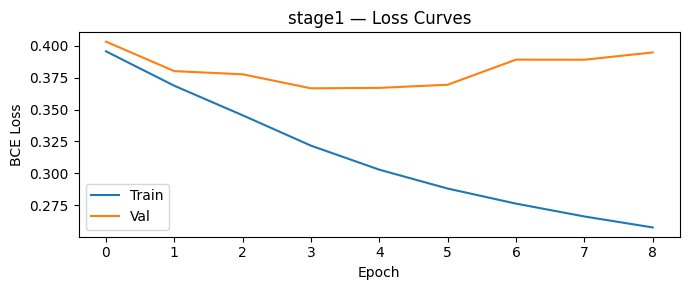

  Loaded best weights from best_ncf_stage1.pt


In [15]:
# Stage 1 config
STAGE1_EMB_COL  = "item_semantic_embedding_static"
STATIC_EMB_DIM  = 384

# Build datasets
def make_loaders_s1(train_neg_df, val_df, test_df, emb_col):
    # Merge embedding onto train negatives
    emb_lookup = train_enc[[
        "item_idx", emb_col]].drop_duplicates("item_idx").set_index("item_idx")

    def add_emb(df):
        d = df.copy()
        d[emb_col] = d["item_idx"].map(
            emb_lookup[emb_col].to_dict()
        ).apply(lambda x: x if isinstance(x, np.ndarray)
                else np.zeros(STATIC_EMB_DIM, dtype=np.float32))
        return d

    tr = add_emb(train_neg_df)
    vl = add_emb(val_df.assign(label=1))
    return (
        DataLoader(FeatureNCFDataset(tr,  emb_col=emb_col), batch_size=2048, shuffle=True),
        DataLoader(FeatureNCFDataset(vl,  emb_col=emb_col), batch_size=2048, shuffle=False),
    )

# Add embedding to train negatives
emb_lookup_dict = (
    train_enc[["item_idx", STAGE1_EMB_COL]]
    .drop_duplicates("item_idx")
    .set_index("item_idx")[STAGE1_EMB_COL]
    .to_dict()
)
train_with_neg_s1 = train_with_neg.copy()
train_with_neg_s1[STAGE1_EMB_COL] = train_with_neg_s1["item_idx"].map(
    emb_lookup_dict
).apply(lambda x: x if isinstance(x, np.ndarray)
        else np.zeros(STATIC_EMB_DIM, dtype=np.float32))

val_enc_s1 = val_enc.copy(); val_enc_s1["label"] = 1

train_loader_s1 = DataLoader(
    FeatureNCFDataset(train_with_neg_s1, emb_col=STAGE1_EMB_COL),
    batch_size=2048, shuffle=True)
val_loader_s1   = DataLoader(
    FeatureNCFDataset(val_enc_s1, emb_col=STAGE1_EMB_COL),
    batch_size=2048, shuffle=False)

# Build and train model
model_s1 = FeatureEnhancedNCF(
    num_users, num_items,
    static_emb_dim=STATIC_EMB_DIM
).to(DEVICE)

print("Training Stage 1...")
model_s1 = train_stage(model_s1, train_loader_s1, val_loader_s1, "stage1")

In [16]:
# Evaluate Stage 1
model_s1.load_state_dict(torch.load("best_ncf_stage1.pt", map_location=DEVICE))
results_s1 = evaluate_stage(
    model_s1,
    eval_rows,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    "Stage 1",
    item_static_df=item_static_all,
    emb_col=STAGE1_EMB_COL,
    cat_cols=None,
    static_num_cols=None,
    temporal_num_cols=None,
    stage_num_scaler=None,
    EVAL_NEG_SAMPLES=999
)

all_preds_rank_s1 = results_s1["all_preds_rank"]
all_targets_rank_s1 = results_s1["all_targets_rank"]
eval_user_ids_s1 = results_s1["eval_user_ids"]

Evaluating Stage 1: 100%|██████████| 5000/5000 [00:05<00:00, 885.13it/s]



  Stage 1 — Results (K=10, 5,000 users)
  HR@10  : 0.5262
  MAP@10 : 0.4419
  nDCG@10: 0.4615


In [17]:
user_train_counts_seg_fix = train_df.groupby("user_id").size()

def activity_bucket_3way_fix(n):
    if 1 <= n <= 5:
        return "Low (1-5)"
    elif 6 <= n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

seg_results_3way_s1 = {}

for seg_name_fix in ["Low (1-5)", "Medium (6-38)", "High (39+)", "All"]:
    seg_preds_fix = []
    seg_targets_fix = []

    for idx_fix, uid_fix in enumerate(eval_user_ids_s1):
        n_train_fix = int(user_train_counts_seg_fix.get(uid_fix, 0))
        bucket_fix = activity_bucket_3way_fix(n_train_fix)

        if seg_name_fix != "All" and bucket_fix != seg_name_fix:
            continue

        seg_preds_fix.append(all_preds_rank_s1[idx_fix])
        seg_targets_fix.append(all_targets_rank_s1[idx_fix])

    if not seg_preds_fix:
        print(f"\n{seg_name_fix}: no users found")
        continue

    seg_preds_fix_arr = np.array(seg_preds_fix)
    seg_targets_fix_arr = np.array(seg_targets_fix)

    hr_fix = hit_rate_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    map_fix = map_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    ndcg_fix = ndcg_at_k_rank(seg_preds_fix_arr, seg_targets_fix_arr, k=K)

    seg_results_3way_s1[seg_name_fix] = {
        "n_users": len(seg_targets_fix_arr),
        f"HR@{K}": round(hr_fix, 4),
        f"MAP@{K}": round(map_fix, 4),
        f"nDCG@{K}": round(ndcg_fix, 4),
    }

    print(f"\n{seg_name_fix} ({len(seg_targets_fix_arr):,} users)")
    print(f"  HR@{K}: {hr_fix:.4f}  MAP@{K}: {map_fix:.4f}  nDCG@{K}: {ndcg_fix:.4f}")

seg_df_3way_s1 = pd.DataFrame(seg_results_3way_s1).T
print("\nSummary table:")
print(seg_df_3way_s1.to_string())


Low (1-5) (2,337 users)
  HR@10: 0.5306  MAP@10: 0.4176  nDCG@10: 0.4441

Medium (6-38) (2,144 users)
  HR@10: 0.5028  MAP@10: 0.4346  nDCG@10: 0.4503

High (39+) (519 users)
  HR@10: 0.6031  MAP@10: 0.5813  nDCG@10: 0.5862

All (5,000 users)
  HR@10: 0.5262  MAP@10: 0.4419  nDCG@10: 0.4615

Summary table:
               n_users   HR@10  MAP@10  nDCG@10
Low (1-5)       2337.0  0.5306  0.4176   0.4441
Medium (6-38)   2144.0  0.5028  0.4346   0.4503
High (39+)       519.0  0.6031  0.5813   0.5862
All             5000.0  0.5262  0.4419   0.4615


## 13. Stage 2 — + Structured Item Metadata + Item Temporal Popularity

Adds:
- Structured metadata: `num_pages`, `publication_year`, `format_collapsed`, `is_ebook`, `language_code_collapsed`, `main_author_id`
- Item temporal popularity: `book_interactions_count_before_t`, `days_since_book_last_interaction`, `author_interactions_count_before_t`

In [18]:
# Stage 1 config
STAGE1_EMB_COL  = "item_semantic_embedding_static"
STATIC_EMB_DIM  = 384

Attaching Stage 2 temporal features [val]: 100%|██████████| 1317799/1317799 [00:08<00:00, 146968.13it/s]


Training Stage 2...


  [stage2] Epoch 01  Train: 0.3886  Val: 0.3763
    ✓ Saved (val: 0.3763)


  [stage2] Epoch 02  Train: 0.3566  Val: 0.3705
    ✓ Saved (val: 0.3705)


  [stage2] Epoch 03  Train: 0.3271  Val: 0.3713


...

  [stage2] Epoch 05  Train: 0.2871  Val: 0.3852


  [stage2] Epoch 06  Train: 0.2732  Val: 0.3831


  [stage2] Epoch 07  Train: 0.2614  Val: 0.3886


  [stage2] Epoch 08  Train: 0.2512  Val: 0.3786


  [stage2] Epoch 09  Train: 0.2421  Val: 0.3912
  Early stopping at epoch 9.


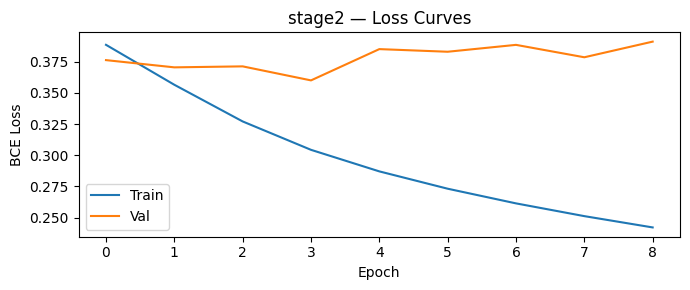

  Loaded best weights from best_ncf_stage2.pt


In [19]:
## 12. Stage 2 — + Structured Item Metadata + Item Temporal Popularity

STAGE2_STATIC_NUM_COLS = ["num_pages", "publication_year", "is_ebook"]
STAGE2_TEMPORAL_NUM_COLS = [
    "book_interactions_count_before_t",
    "days_since_book_last_interaction",
    "author_interactions_count_before_t",
]
STAGE2_NUM_COLS = STAGE2_STATIC_NUM_COLS + STAGE2_TEMPORAL_NUM_COLS
STAGE2_CAT_COLS = ["format_idx", "lang_idx", "author_idx"]

STAGE2_STATIC_NUM_COLS = [c for c in STAGE2_STATIC_NUM_COLS if c in train_enc.columns]

# Static item lookups
static_num_lookups = {
    col: (
        train_enc[["item_idx", col]]
        .drop_duplicates("item_idx")
        .set_index("item_idx")[col]
        .to_dict()
    )
    for col in STAGE2_STATIC_NUM_COLS
}

cat_lookups = {
    col: (
        train_enc[["item_idx", col]]
        .drop_duplicates("item_idx")
        .set_index("item_idx")[col]
        .to_dict()
    )
    for col in STAGE2_CAT_COLS
}

idx_to_item = {idx: item for item, idx in item_to_idx.items()}

# Stage 1 static embedding lookup
emb_lookup_dict = (
    train_enc[["item_idx", STAGE1_EMB_COL]]
    .drop_duplicates("item_idx")
    .set_index("item_idx")[STAGE1_EMB_COL]
    .to_dict()
)

def attach_stage2_features(df, split_name="train"):
    d = df.copy()

    # Drop existing Stage 2 numeric columns first to avoid duplicate names
    cols_to_drop = [c for c in STAGE2_NUM_COLS if c in d.columns]
    if cols_to_drop:
        d = d.drop(columns=cols_to_drop)

    # Static embedding
    d[STAGE1_EMB_COL] = d["item_idx"].map(emb_lookup_dict).apply(
        lambda x: x if isinstance(x, np.ndarray)
        else np.zeros(STATIC_EMB_DIM, dtype=np.float32)
    )

    # Static numeric item features
    for col in STAGE2_STATIC_NUM_COLS:
        d[col] = d["item_idx"].map(static_num_lookups[col]).fillna(0)

    # Static categorical item features
    for col in STAGE2_CAT_COLS:
        d[col] = d["item_idx"].map(cat_lookups[col]).fillna(0).astype(int)

    # Dynamic temporal item features
    temporal_rows = []
    for row in tqdm(
        d.itertuples(index=False),
        total=len(d),
        desc=f"Attaching Stage 2 temporal features [{split_name}]"
    ):
        book_id = idx_to_item[row.item_idx]
        feats = compute_item_temporal_features(book_id, row.event_time)
        temporal_rows.append(feats)

    temporal_df = pd.DataFrame(temporal_rows, index=d.index)

    # Assign explicitly instead of concat
    for col in STAGE2_TEMPORAL_NUM_COLS:
        d[col] = temporal_df[col].values

    # Ensure numeric dtype
    for col in STAGE2_NUM_COLS:
        d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0).astype(np.float32)

    return d

# Build train / val data
train_with_neg_s1 = train_with_neg.copy()
train_with_neg_s2 = attach_stage2_features(train_with_neg_s1, split_name="train")

val_enc_s2 = val_enc.copy()
val_enc_s2["label"] = 1
val_enc_s2 = attach_stage2_features(val_enc_s2, split_name="val")

# Fit a Stage 2 scaler on the actual Stage 2 training rows
stage2_num_scaler = StandardScaler()
train_with_neg_s2[STAGE2_NUM_COLS] = stage2_num_scaler.fit_transform(
    train_with_neg_s2[STAGE2_NUM_COLS].fillna(0)
)
val_enc_s2[STAGE2_NUM_COLS] = stage2_num_scaler.transform(
    val_enc_s2[STAGE2_NUM_COLS].fillna(0)
)

train_loader_s2 = DataLoader(
    FeatureNCFDataset(
        train_with_neg_s2,
        emb_col=STAGE1_EMB_COL,
        cat_cols=STAGE2_CAT_COLS,
        feature_cols=STAGE2_NUM_COLS
    ),
    batch_size=2048,
    shuffle=True
)

val_loader_s2 = DataLoader(
    FeatureNCFDataset(
        val_enc_s2,
        emb_col=STAGE1_EMB_COL,
        cat_cols=STAGE2_CAT_COLS,
        feature_cols=STAGE2_NUM_COLS
    ),
    batch_size=2048,
    shuffle=False
)

model_s2 = FeatureEnhancedNCF(
    num_users,
    num_items,
    static_emb_dim=STATIC_EMB_DIM,
    num_formats=num_formats,
    num_langs=num_langs,
    num_authors=num_authors,
    num_numerical=len(STAGE2_NUM_COLS)
).to(DEVICE)

print("Training Stage 2...")
model_s2 = train_stage(model_s2, train_loader_s2, val_loader_s2, "stage2")

In [20]:
# Evaluate Stage 2

model_s2.load_state_dict(torch.load("best_ncf_stage2.pt", map_location=DEVICE))
results_s2 = evaluate_stage(
    model_s2,
    eval_rows,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    "Stage 2",
    item_static_df=item_static_all,
    emb_col=STAGE1_EMB_COL,
    cat_cols=STAGE2_CAT_COLS,
    static_num_cols=STAGE2_STATIC_NUM_COLS,
    temporal_num_cols=STAGE2_TEMPORAL_NUM_COLS,
    stage_num_scaler=stage2_num_scaler,
    EVAL_NEG_SAMPLES=999
)

all_preds_rank = results_s2["all_preds_rank"]
all_targets_rank = results_s2["all_targets_rank"]
eval_user_ids = results_s2["eval_user_ids"]

Evaluating Stage 2: 100%|██████████| 5000/5000 [00:38<00:00, 130.69it/s]



  Stage 2 — Results (K=10, 5,000 users)
  HR@10  : 0.4526
  MAP@10 : 0.3745
  nDCG@10: 0.3928


In [21]:
user_train_counts_seg_fix = train_df.groupby("user_id").size()

def activity_bucket_3way_fix(n):
    if 1 <= n <= 5:
        return "Low (1-5)"
    elif 6 <= n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

seg_results_3way_fix = {}

for seg_name_fix in ["Low (1-5)", "Medium (6-38)", "High (39+)", "All"]:
    seg_preds_fix = []
    seg_targets_fix = []

    for idx_fix, uid_fix in enumerate(eval_user_ids):
        n_train_fix = int(user_train_counts_seg_fix.get(uid_fix, 0))
        bucket_fix = activity_bucket_3way_fix(n_train_fix)

        if seg_name_fix != "All" and bucket_fix != seg_name_fix:
            continue

        seg_preds_fix.append(all_preds_rank[idx_fix])
        seg_targets_fix.append(all_targets_rank[idx_fix])

    if not seg_preds_fix:
        print(f"\n{seg_name_fix}: no users found")
        continue

    seg_preds_fix_arr = np.array(seg_preds_fix)
    seg_targets_fix_arr = np.array(seg_targets_fix)

    hr_fix = hit_rate_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    map_fix = map_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    ndcg_fix = ndcg_at_k_rank(seg_preds_fix_arr, seg_targets_fix_arr, k=K)

    seg_results_3way_fix[seg_name_fix] = {
        "n_users": len(seg_targets_fix_arr),
        f"HR@{K}": round(hr_fix, 4),
        f"MAP@{K}": round(map_fix, 4),
        f"nDCG@{K}": round(ndcg_fix, 4),
    }

    print(f"\n{seg_name_fix} ({len(seg_targets_fix_arr):,} users)")
    print(f"  HR@{K}: {hr_fix:.4f}  MAP@{K}: {map_fix:.4f}  nDCG@{K}: {ndcg_fix:.4f}")

seg_df_3way_fix = pd.DataFrame(seg_results_3way_fix).T
print("\nSummary table:")
print(seg_df_3way_fix.to_string())


Low (1-5) (2,337 users)
  HR@10: 0.4613  MAP@10: 0.3552  nDCG@10: 0.3802

Medium (6-38) (2,144 users)
  HR@10: 0.4319  MAP@10: 0.3706  nDCG@10: 0.3849

High (39+) (519 users)
  HR@10: 0.4990  MAP@10: 0.4771  nDCG@10: 0.4820

All (5,000 users)
  HR@10: 0.4526  MAP@10: 0.3745  nDCG@10: 0.3928

Summary table:
               n_users   HR@10  MAP@10  nDCG@10
Low (1-5)       2337.0  0.4613  0.3552   0.3802
Medium (6-38)   2144.0  0.4319  0.3706   0.3849
High (39+)       519.0  0.4990  0.4771   0.4820
All             5000.0  0.4526  0.3745   0.3928


## Analysis of Stage 1&2 Results

Our segment analysis showed that recommendation quality varied systematically with user activity level. In both Stage 1 and Stage 2, performance was strongest for users with the richest interaction histories and weaker for the low- and medium-activity groups. In Stage 1, the high-activity segment achieved HR@10 = 0.6012, MAP@10 = 0.5821, and nDCG@10 = 0.5863, clearly above the overall averages of 0.5256, 0.4439, and 0.4629. A similar pattern remained in Stage 2, although at lower levels throughout. This indicates that the models learned more effectively when more user history was available, and that users with limited past interactions were harder to personalise for.

Comparing the two stages, Stage 2 underperformed Stage 1 across every activity segment and every ranking metric. The drop was therefore broad-based rather than driven by a single subgroup. This suggests that the additional Stage 2 features did not improve ranking quality under the current setup.

The loss curves further showed overfitting in both stages, with training loss continuing to improve while validation loss worsened after a point. This indicates that the models were fitting patterns specific to the training data that did not generalise as well to held-out interactions. Taken together, these results suggest that although richer feature sets increase model complexity, they do not necessarily improve recommendation performance. Under the current data and training setup, the simpler Stage 1 model generalised better than Stage 2.